# Explorador Temático de Entrevistas Cualitativas

Herramienta exploratoria en Python para analizar transcripciones de entrevistas (`.txt`) mediante Procesamiento de Lenguaje Natural (spaCy) y análisis estadístico del vocabulario.

El flujo identifica expresiones léxicas relevantes a partir de la estructura gramatical de las palabras y genera indicadores de:

- **Frecuencia:** cuántas veces aparece cada concepto en el corpus.
- **Cobertura:** en cuántas entrevistas aparece.
- **Relevancia léxica:** puntuación TF-IDF.

> **Nota metodológica:** la herramienta apoya la exploración inicial del corpus. No reemplaza la lectura contextual, la codificación ni la interpretación cualitativa del investigador.

## Cómo utilizarla

1. Ejecuta la celda de código.
2. Selecciona tus archivos `.txt` en formato UTF-8.
3. Revisa el gráfico de conceptos principales.
4. Descarga la matriz Excel con los resultados y su distribución por entrevista.

## Adaptación a otros corpus

Para trabajar con entrevistas o transcripciones de otro estudio, los principales parámetros que puedes ajustar son:

- `STOP_LEMAS_EXTRA`: palabras que quieras excluir del análisis.
- `VERBOS_RUIDO`: verbos conversacionales frecuentes que generen ruido.
- `min_df`: número mínimo de entrevistas en las que debe aparecer un concepto.

La configuración actual prioriza conceptos presentes en al menos **2 entrevistas**, reduciendo la influencia de menciones aisladas.

Para conocer el procesamiento lingüístico, los criterios de filtrado y las decisiones metodológicas del análisis, revisa el **README del repositorio**.

In [1]:
# Descarga del modelo de lenguaje (luego pedirá reiniciar el 'Entorno de ejecución')
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 86.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Selecciona tus archivos .txt:


Saving Alaya 20 01.txt to Alaya 20 01.txt
Saving Jaime 29 02 2020.txt to Jaime 29 02 2020.txt
Saving José 19 01.txt to José 19 01.txt
Saving juan 19 01.txt to juan 19 01.txt
Saving Luis 2 03 2020.txt to Luis 2 03 2020.txt
Saving nelson 02 03 2020.txt to nelson 02 03 2020.txt

Análisis completado: Matriz_Sociologica_Resultados.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

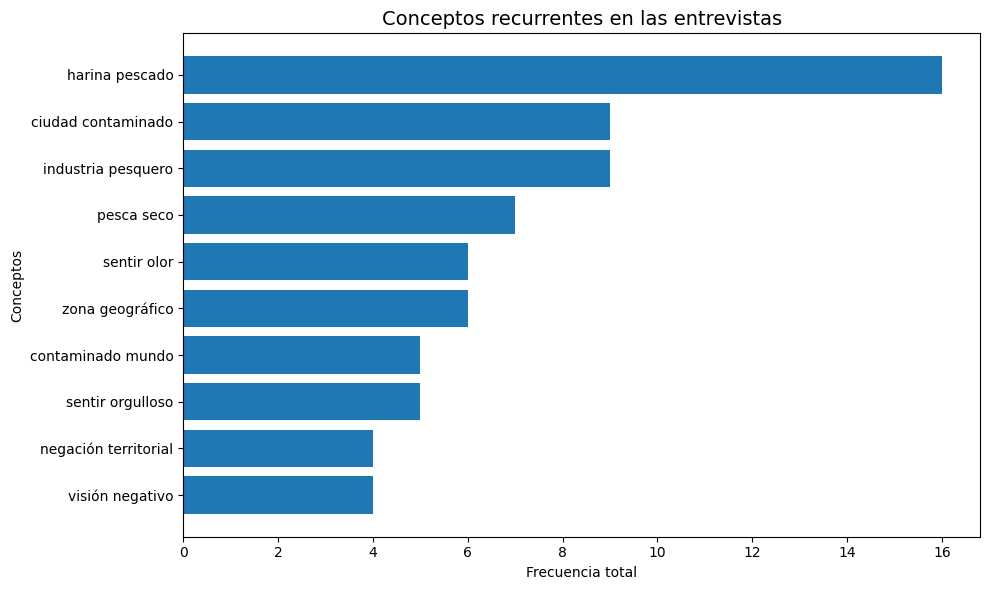


Top 10 conceptos:
            Concepto  Frecuencia total  Entrevistas con presencia  TF-IDF promedio
      harina pescado                16                          6         0.282867
  industria pesquero                 9                          5         0.180920
  ciudad contaminado                 9                          4         0.216480
          pesca seco                 7                          2         0.160869
     zona geográfico                 6                          5         0.115175
         sentir olor                 6                          2         0.145091
    sentir orgulloso                 5                          4         0.131505
   contaminado mundo                 5                          4         0.129653
negación territorial                 4                          3         0.121289
     visión negativo                 4                          2         0.124757


In [2]:
import pandas as pd
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import matplotlib.pyplot as plt
from google.colab import files

# Modelo lingüístico en español
nlp = spacy.load("es_core_news_sm")

# CARGA DE ENTREVISTAS
print("Selecciona tus archivos .txt:")
uploaded = files.upload()

# CONFIGURACIÓN DEL PREPROCESAMIENTO

# Palabras que suelen generar ruido en transcripciones.
STOP_LEMAS_EXTRA = {
    "él", "ella", "ellos", "ellas", "ello", "esto", "eso",
    "aquel", "aquella", "aquello", "uno", "una", "unos", "unas",
    "este", "esta", "estos", "estas",
}

# Verbos muy frecuentes en entrevistas/transcripciones que suelen formar frases poco analíticas ("ver él", "decir él", etc.).
# Se excluyen SOLO cuando funcionan como parte de una frase candidata.
VERBOS_RUIDO = {
    "decir", "ver", "dar", "venir", "hacer", "tener", "ir", "poder",
    "querer", "saber", "poner", "pasar", "llevar"
}

# Patrones que sí queremos considerar como conceptos/frases.
# NOUN+NOUN -> harina pescado
# NOUN+ADJ  -> industria pesquera
# ADJ+NOUN  -> identidad territorial
# VERB+NOUN -> contaminar ciudad
# VERB+ADJ  -> sentir orgulloso
PATRONES_VALIDOS = {
    ("NOUN", "NOUN"),
    ("NOUN", "ADJ"),
    ("ADJ", "NOUN"),
    ("VERB", "NOUN"),
    ("VERB", "ADJ"),
}

def lema_valido(token):
    """Filtra palabras funcionales, puntuación y artefactos."""
    lema = token.lemma_.lower().strip()

    if not lema or len(lema) <= 2:
        return False

    if token.is_punct or token.like_num or token.is_space:
        return False

    if token.is_stop:
        return False

    if lema in STOP_LEMAS_EXTRA:
        return False

    if token.pos_ not in {"NOUN", "VERB", "ADJ"}:
        return False

    return True


def extraer_frases(sent):
    """
    Extrae pares lingüísticamente plausibles.
    Permite una palabra funcional intermedia, por ejemplo:
    'harina de pescado' -> 'harina pescado'
    pero evita frases como 'ver él'.
    """
    tokens = list(sent)
    frases = []

    for i in range(len(tokens)):
        t1 = tokens[i]

        if not lema_valido(t1):
            continue

        # Caso 1: palabras consecutivas
        candidatos = [(i + 1, [])]

        # Caso 2: una palabra funcional intermedia
        if i + 2 < len(tokens):
            candidatos.append((i + 2, [tokens[i + 1]]))

        for j, intermedios in candidatos:
            if j >= len(tokens):
                continue

            t2 = tokens[j]

            # No cruzar puntuación.
            if any(t.is_punct for t in intermedios):
                continue

            # Si hay palabra intermedia, debe ser funcional/stopword.
            if intermedios and not all(t.is_stop for t in intermedios):
                continue

            if not lema_valido(t2):
                continue

            patron = (t1.pos_, t2.pos_)

            if patron not in PATRONES_VALIDOS:
                continue

            # Evitar verbos de apoyo cuando generan combinaciones débiles.
            if t1.pos_ == "VERB" and t1.lemma_.lower() in VERBOS_RUIDO:
                continue

            frase = f"{t1.lemma_.lower()}_{t2.lemma_.lower()}"
            frases.append(frase)

    return frases


# PROCESAMIENTO DE CADA ENTREVISTA
nombres_archivos = []
frases_por_entrevista = []

for filename, contenido in uploaded.items():

    if not filename.lower().endswith(".txt"):
        continue

    texto_crudo = contenido.decode("utf-8", errors="ignore")
    doc = nlp(texto_crudo)

    frases = []

    for sent in doc.sents:
        frases.extend(extraer_frases(sent))

    nombres_archivos.append(filename)
    frases_por_entrevista.append(" ".join(frases))

if len(frases_por_entrevista) == 0:
    print("No se encontraron archivos .txt válidos.")

else:

    df_entrevistas = pd.DataFrame({
        "Archivo": nombres_archivos,
        "Texto": frases_por_entrevista
    })


    # FRECUENCIA DE CONCEPTOS

    vectorizer = CountVectorizer(
        lowercase=False,
        token_pattern=r"(?u)\b\w+(?:_\w+)+\b",
        min_df=2,       # aparece en al menos 2 entrevistas
        max_df=1.0
    )

    matriz_frecuencias = vectorizer.fit_transform(
        df_entrevistas["Texto"]
    )

    vocabulario = vectorizer.get_feature_names_out()

    frecuencia_total = matriz_frecuencias.sum(axis=0).A1

    # Número de entrevistas donde aparece el concepto
    cobertura = (matriz_frecuencias > 0).sum(axis=0).A1

    # --------------------------------------------------------
    # RELEVANCIA TF-IDF
    # --------------------------------------------------------
    tfidf = TfidfTransformer()
    matriz_tfidf = tfidf.fit_transform(matriz_frecuencias)

    relevancia = matriz_tfidf.mean(axis=0).A1

    df_resultados = pd.DataFrame({
        "Concepto": [x.replace("_", " ") for x in vocabulario],
        "Frecuencia total": frecuencia_total,
        "Entrevistas con presencia": cobertura,
        "TF-IDF promedio": relevancia
    })

    # Orden principal: frecuencia, manteniendo la cobertura y relevancia.
    df_resultados = (
        df_resultados
        .sort_values(
            by=["Frecuencia total", "Entrevistas con presencia", "TF-IDF promedio"],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )


    # ELIMINACIÓN DE RUIDO ESPECÍFICO

    ruido_conocido = {
        "tipo cosa",
        "tema análisis"
    }

    df_resultados = df_resultados[
        ~df_resultados["Concepto"].isin(ruido_conocido)
    ]

    df_exportar = df_resultados.head(50)


    #  EXPORTACIÓN A EXCEL

    nombre_excel = "Matriz_Sociologica_Resultados.xlsx"

    # Matriz concepto x entrevista (alfabética por defecto)
    df_matriz = pd.DataFrame(
        matriz_frecuencias.toarray(),
        columns=[x.replace("_", " ") for x in vocabulario],
        index=nombres_archivos
    ).T.reset_index().rename(columns={"index": "Concepto"})

    # AJUSTE DE CALIDAD: Sincronizar la matriz con el Top 50 de resultados
    conceptos_top = df_exportar["Concepto"].tolist()
    # Filtramos la matriz para que solo tenga los 50 conceptos más frecuentes
    df_matriz_top = df_matriz[df_matriz["Concepto"].isin(conceptos_top)]
    # Ordenamos la matriz de mayor a menor frecuencia para que sea idéntica a la hoja 1
    df_matriz_top = df_matriz_top.set_index("Concepto").loc[conceptos_top].reset_index()

    with pd.ExcelWriter(nombre_excel, engine="openpyxl") as writer:
        df_exportar.to_excel(
            writer,
            sheet_name="Resultados",
            index=False
        )

        # Exportamos la matriz ya filtrada y ordenada
        df_matriz_top.to_excel(
            writer,
            sheet_name="Por entrevista",
            index=False
        )

    print(f"\nAnálisis completado: {nombre_excel}")
    files.download(nombre_excel)


    # VISUALIZACIÓN

    df_top10 = df_exportar.head(10).sort_values("Frecuencia total")

    plt.figure(figsize=(10, 6))

    plt.barh(
        df_top10["Concepto"],
        df_top10["Frecuencia total"]
    )

    plt.title(
        "Conceptos recurrentes en las entrevistas",
        fontsize=14
    )
    plt.xlabel("Frecuencia total")
    plt.ylabel("Conceptos")

    plt.tight_layout()
    plt.show()


    # RESUMEN PARA PRESENTACIÓN

    print("\nTop 10 conceptos:")
    print(
        df_exportar[
            ["Concepto", "Frecuencia total",
             "Entrevistas con presencia", "TF-IDF promedio"]
        ].head(10).to_string(index=False)
    )